In [ ]:
!kaggle datasets download sehriyarmemmedli/mnist-dataset
!unzip mnist-dataset.zip

import pandas as pd
import numpy as np
df = pd.read_csv('mnist_data.csv')
X = df.iloc[:, :-1].to_numpy()
y = df.iloc[:, -1].to_numpy()
X.shape,y.shape

Dataset URL: https://www.kaggle.com/datasets/sehriyarmemmedli/mnist-dataset
License(s): apache-2.0
 92% 14.0M/15.2M [00:01<00:00, 18.5MB/s]
100% 15.2M/15.2M [00:01<00:00, 14.0MB/s]
Archive:  mnist-dataset.zip
  inflating: mnist_data.csv          


((70000, 784), (70000,))

In [ ]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
X.shape

(70000, 784)

In [ ]:
y

array([5, 0, 4, ..., 4, 5, 6])

In [ ]:
X[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [ ]:
X[0].shape

(784,)

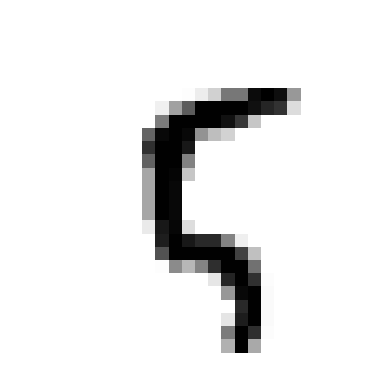

In [ ]:
import matplotlib.pyplot as plt
def plot_digit(data):
    image=data.reshape(28,28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')

plot_digit(X[100])

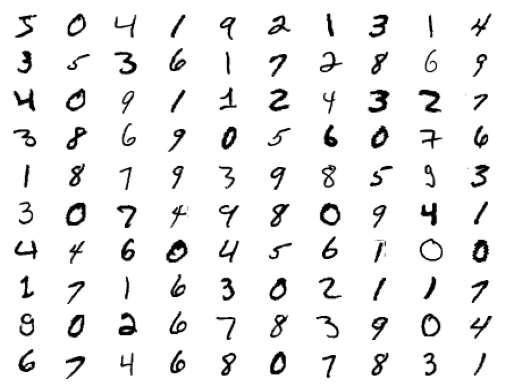

In [ ]:
for idx, image in enumerate(X[:100]):
    plt.subplot(10,10,idx+1)
    plot_digit(image)
plt.show()

In [ ]:
X_train,X_test,y_train,y_test = X[:60000],X[60000:],y[:60000],y[60000:]

In [ ]:
y_train_5 = y_train == 5
y_test_5 =  y_test ==5

In [ ]:
y_train_5

array([ True, False, False, ...,  True, False, False])

In [ ]:
y_test_5

array([False, False, False, ..., False,  True, False])

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train , y_train_5)
sgd_clf.score(X_test , y_test_5)

0.9492

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf=DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train_5)
dummy_clf.score(X_test, y_test_5)

0.9108

In [ ]:
import pandas as pd

pd.Series(y_train_5).value_counts() / len(y_train_5)

,count
False,0.90965
True,0.09035


In [ ]:
from sklearn.model_selection import cross_val_predict

y_preds = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
y_preds

array([ True, False, False, ...,  True, False, False])

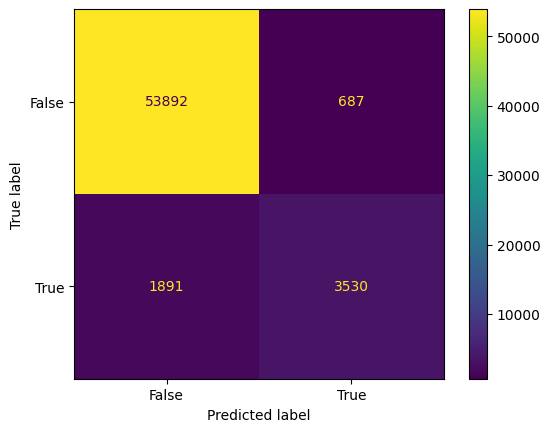

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_train_5, y_preds);

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_score(y_train_5, y_preds)

0.8370879772350012

In [ ]:
recall_score(y_train_5,y_preds)

0.6511713705958311

In [ ]:
f1_score(y_train_5,y_preds)

0.7325171197343847

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_preds)

In [ ]:
cm

array([[53892,   687],
       [ 1891,  3530]])

In [ ]:
cm[1,1] / (cm[1,1]+cm[0,1])

0.8370879772350012

In [ ]:
cm[1,1] / (cm[1,1]+cm[1,0])

0.6511713705958311

In [ ]:
sgd_clf.decision_function(X_train[[0]])

array([2164.22030239])

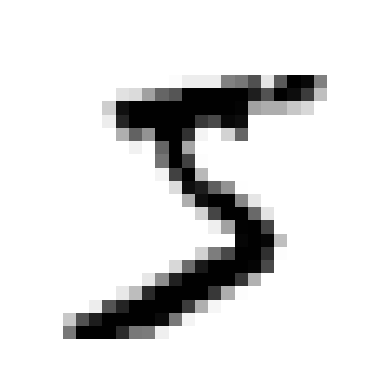

In [ ]:
plot_digit(X_train[0])

In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function')

In [ ]:
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447])

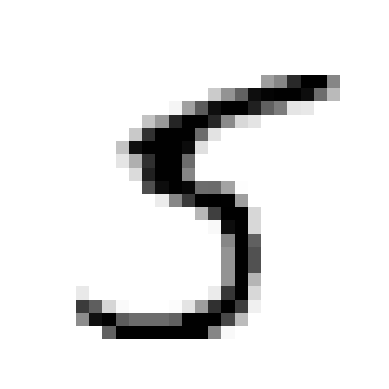

In [ ]:
plot_digit(X_train[-3])

In [ ]:
np.argmax(y_scores)

47320

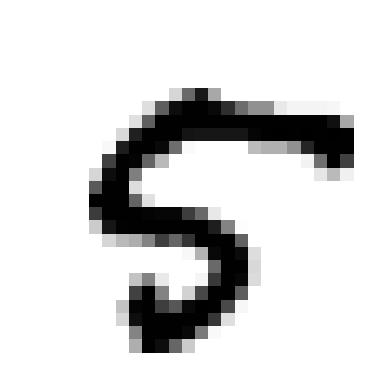

In [ ]:
plot_digit(X_train[47320])

In [ ]:
np.argmin(y_scores)

40394

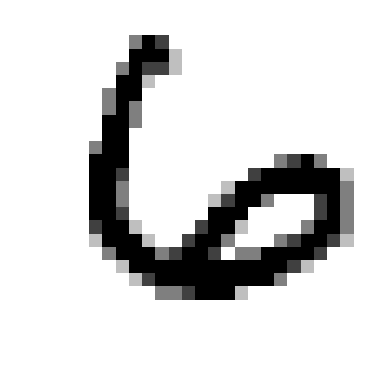

In [ ]:
plot_digit(X_train[40394])

In [ ]:
y_scores > 3000

array([False, False, False, ...,  True, False, False])

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds=precision_recall_curve(y_train_5, y_scores)

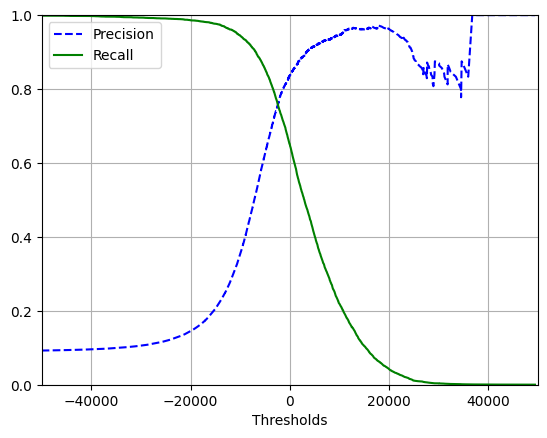

In [ ]:
plt.plot(thresholds, precisions[:-1],'b--',label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.xlabel('Thresholds')
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.legend()
plt.show()

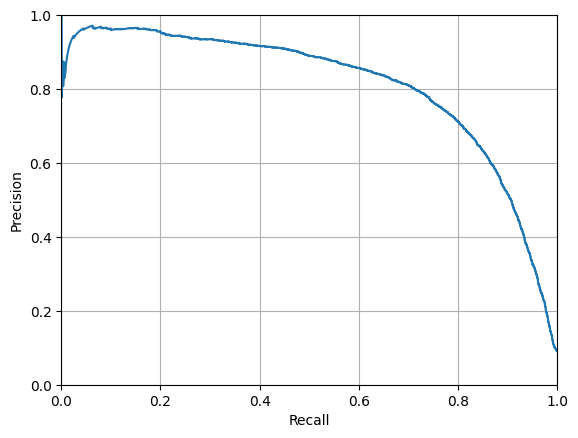

In [ ]:
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.axis([0,1,0,1])
plt.grid()
plt.show()

In [ ]:
precisions

array([0.09035   , 0.09035151, 0.09035301, ..., 1.        , 1.        ,
       1.        ])

In [ ]:
idx_for_90_precision=np.argmax(precisions >= 0.9)
idx_for_90_precision

57109

In [ ]:
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

3370.0194991439557

In [ ]:
preds_for_90_precision = y_scores > threshold_for_90_precision
preds_for_90_precision

array([False, False, False, ...,  True, False, False])

In [ ]:
precision_score(y_train_5, preds_for_90_precision)

0.9

In [ ]:
recall_score(y_train_5,preds_for_90_precision)

0.47980077476480354

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds=roc_curve(y_train_5,y_scores)

ValueError: 'k==' is not a valid format string (unrecognized character '=')

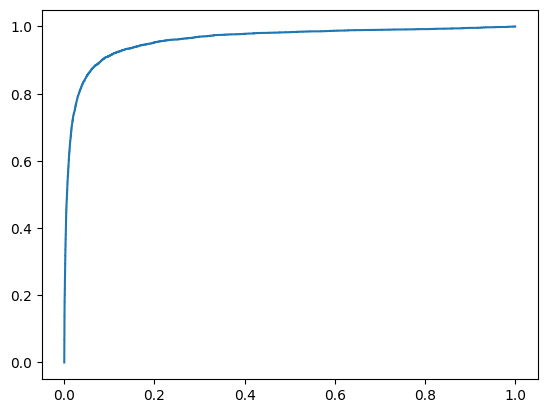

In [ ]:
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'k==')
plt.plot([0,1,0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Postive Rate')

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5,y_scores)

0.9604938554008616

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_clf=RandomForestClassifier(random_state=42)

y_scores_forest=cross_val_predict(forest_clf,X_train,y_train_5,cv=3,method='predict_proba')
y_scores_forest

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       ...,
       [0.02, 0.98],
       [0.92, 0.08],
       [0.94, 0.06]])

In [ ]:
y_scores_forest_pos = y_scores_forest[:,1]
y_scores_forest_pos

array([0.89, 0.01, 0.04, ..., 0.98, 0.08, 0.06])

In [ ]:
precisions_forest, recalls_forest, thresholds_forest=precision_recall_curve(y_train_5,y_scores_forest_pos)

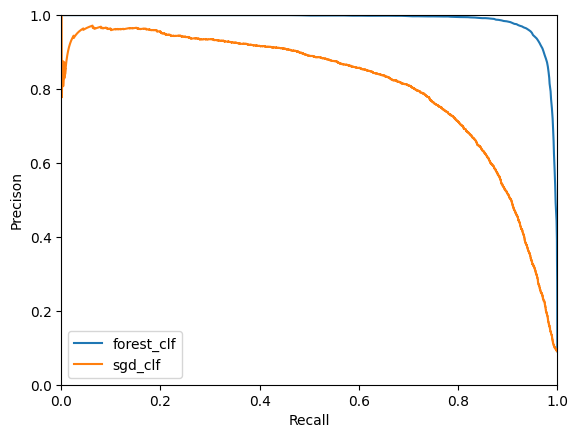

In [ ]:
plt.plot(recalls_forest, precisions_forest, label = 'forest_clf' )
plt.plot(recalls, precisions, label = 'sgd_clf' )
plt.legend()
plt.axis([0,1,0,1])
plt.xlabel('Recall')
plt.ylabel('Precison')
plt.show()

In [ ]:
forest_preds= y_scores_forest_pos>=0.3

In [ ]:
precision_score(y_train_5, forest_preds)

0.9412727272727273

In [ ]:
recall_score(y_train_5, forest_preds)

0.9549898542704298

In [ ]:
f1_score(y_train_5, forest_preds)

0.9480816775020603

#MultiClass Classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf=RandomForestClassifier(random_state=42)
rnd_clf.fit(X_train,y_train)
rnd_clf.score(X_test,y_test)

0.9705

In [ ]:
rnd_clf.predict(X_test[[0]])

array([7])

In [ ]:
from sklearn.svm import SVC

svm_clf = SVC()
svm_clf.fit(X_train[:3000], y_train[:3000])
svm_clf.score(X_test,y_test)

0.9408

In [ ]:
svm_clf.predict(X_test[[0]])

array([7])

In [ ]:
#OVR/OVA --> One versus Rest/All --> 10 clssses --> 10 models
#OVO --> One versus one --> 10 models --> 45 models

In [ ]:
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

ovo_clf = OneVsRestClassifier(SVC())
ovo_clf.fit(X_train[:3000], y_train[:3000])

OneVsRestClassifier(estimator=SVC())

In [ ]:
cross_val_score(sgd_clf,X_train[:3000],y_train[:3000],cv=3,scoring='accuracy')

array([0.822, 0.837, 0.856])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train.astype(np.float64))
X_test_scaled=scaler.transform(X_test.astype(np.float64))
cross_val_score(sgd_clf,X_train_scaled[:3000],y_train[:3000],cv=3,scoring='accuracy')

array([0.85 , 0.853, 0.88 ])

In [ ]:
# sgd_predicts=cross_val_predict(sgd_clf,X_train_scaled,y_train,cv=3)
# ConfusionMatrixDisplay.from_predictions(y_train,sgd_predicts)
# plt.show()

KeyboardInterrupt: 

# MultiLabel Classification

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
y_train_large=y_train>=7
y_train_odd=y_train%2==1
y_multilabel=np.c_[y_train_large,y_train_odd]

knn_clf=KNeighborsClassifier()
knn_clf.fit(X_Train,y_multilabel)

NameError: name 'X_Train' is not defined

In [ ]:
knn_clf.predict(X_test[[0]])

In [ ]:
plot_digit(X_test[0])

# MultiOutput Classification

In [ ]:
noise=np.random.randint(0,100,(len(X_train),784))
X_train_mod=X_train + noise
noise=np.random.randint(0,100, (len(X_test),784))
X_test_mod=X_test+noise
y_train_mod=X_train
y_test_mod=X_test

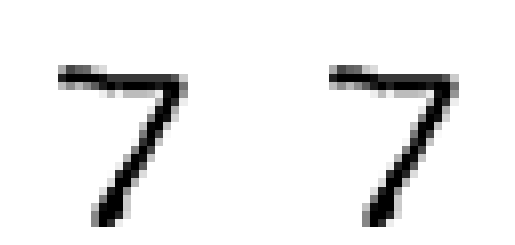

In [ ]:
plt.subplot(121)
plot_digit(y_test_mod[0])
plt.subplot(122)
plot_digit(y_test_mod[0])
plt.show()

In [ ]:
knn_clf.fit(X_train_mod,y_train_mod)

KNeighborsClassifier()

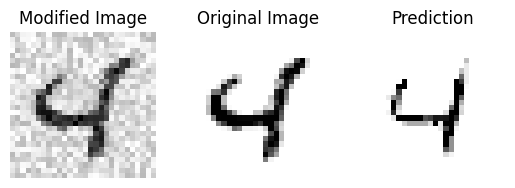

In [ ]:
idx=67
plt.subplot(131)
plt.title("Modified Image")
plot_digit(X_test_mod[idx])
plt.subplot(132)
plt.title("Original Image")
plot_digit(y_test_mod[idx])
plt.subplot(133)
plt.title("Prediction")
plot_digit(knn_clf.predict(X_test_mod[[idx]]))
plt.show()